---
title: "Appendix: YAML Serializer Variance and Token Economics"
type: guide
authors:
  - name: Vadim Rudakov
    email: rudakow.wadim@gmail.com
description: "Empirical analysis showing that YAML token costs are a function of (format, serializer, tokenizer) — not format alone. PyYAML vs yq isolation, semantic fidelity, ranking stability across 5 prompt files."
tags: [prompts, architecture]
date: 2026-03-27
options:
  version: 1.0.0
  birth: 2026-03-27
---

## Problem Statement

The [Format as Architecture](/ai_system_layers/3_prompts/format_as_architecture_signal_noise_in_prompt_delivery.ipynb) handbook and its companion [Token Economics of Prompt Delivery](/ai_system_layers/3_prompts/token_economics_of_prompt_delivery.ipynb) treat format as the sole variable in prompt token cost: "YAML Literal is the most expensive format," "Standard YAML is ~N% cheaper than JSON." Session measurements revealed this framing is incomplete.

Two tools — PyYAML and yq — producing valid, semantically equivalent YAML from the same JSON source yield token counts differing by 100+ tokens, and the **relative ranking of YAML Literal vs Pretty JSON flips** depending on the tool. The token cost of a prompt format is a function of three variables:

$$\text{token\_cost} = f(\text{format},\ \text{serializer},\ \text{tokenizer})$$

This appendix verifies the finding across 5 prompt files, isolates each serializer variable independently, confirms semantic fidelity, and derives a concrete stack recommendation. For a concise summary see [A-26017](/architecture/evidence/analyses/A-26017_yaml_serializer_variance_token_economics.md).

## Setup

In [1]:
import json
import os
import re
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tiktoken
import yaml
from IPython.display import display

enc = tiktoken.get_encoding('cl100k_base')
CONSULTANTS_DIR = Path('../3_prompts/consultants')

# All production prompts above 1 KB (exclude stubs)
PROMPT_FILES = sorted(
    [p for p in CONSULTANTS_DIR.glob('*.json') if p.stat().st_size > 1000],
    key=lambda p: p.stat().st_size,
)

print(f"{'File':<45} {'Size (bytes)':>12}")
print('-' * 59)
for p in PROMPT_FILES:
    print(f"{p.name:<45} {p.stat().st_size:>12,}")

File                                          Size (bytes)
-----------------------------------------------------------
handbook_consultant.json                             5,434
ai_brainstorming_colleague.json                      6,079
devops_consultant.json                              12,199
ai_systems_consultant_hybrid.json                   12,944
local_ai_systems_consultant.json                    13,301


In [2]:
# ── Serializer helpers ────────────────────────────────────────────────────────

def yaml_standard(data, width=80):
    """PyYAML standard YAML. width=80 is the PyYAML default (enables line-wrapping)."""
    return yaml.dump(data, allow_unicode=True, default_flow_style=False,
                     sort_keys=False, width=width)


def yaml_literal(data):
    """PyYAML YAML with literal block scalars (`|`) for all string values."""
    class LiteralStr(str):
        pass

    class LiteralDumper(yaml.Dumper):
        pass

    LiteralDumper.add_representer(
        LiteralStr,
        lambda dumper, val: dumper.represent_scalar('tag:yaml.org,2002:str', val, style='|'),
    )

    def apply_literal(obj):
        if isinstance(obj, str) and '\n' in obj:
            return LiteralStr(obj)
        if isinstance(obj, str):
            return LiteralStr(obj + '\n')
        if isinstance(obj, dict):
            return {k: apply_literal(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [apply_literal(i) for i in obj]
        return obj

    return yaml.dump(apply_literal(data), Dumper=LiteralDumper,
                     allow_unicode=True, default_flow_style=False, sort_keys=False)


def yq_standard(path):
    return subprocess.run(['yq', '-oy', str(path)], capture_output=True, text=True).stdout


def yq_literal(path):
    return subprocess.run(['yq', '-oy', '..style="literal"', str(path)],
                          capture_output=True, text=True).stdout


def tokens(text):
    return len(enc.encode(text))


JSON_VARIANTS = [
    'Original JSON',
    'Minified JSON',
    'Pretty JSON',
]

YAML_VARIANTS = [
    'Standard YAML (PyYAML)',
    'Standard YAML (yq)',
    'YAML Literal (PyYAML)',
    'YAML Literal (yq)',
]

VARIANT_NAMES = JSON_VARIANTS + YAML_VARIANTS


def variants_for(path, data):
    return {
        'Original JSON':          path.read_text(),
        'Minified JSON':          json.dumps(data, ensure_ascii=False, separators=(',', ':')),
        'Pretty JSON':            json.dumps(data, ensure_ascii=False, indent=2),
        'Standard YAML (PyYAML)': yaml_standard(data, width=80),
        'Standard YAML (yq)':     yq_standard(path),
        'YAML Literal (PyYAML)':  yaml_literal(data),
        'YAML Literal (yq)':      yq_literal(path),
    }

(appendix-yaml-a-baseline)=
## A. Baseline: Token Counts Across All Prompt Files

We measure all seven variants on every production prompt file, then compute median deltas relative to Minified JSON. Using the median across 5 files makes the finding robust — not an artifact of one prompt's structure.

In [3]:
# Build long-format DataFrame
records = []
for path in PROMPT_FILES:
    data = json.loads(path.read_text())
    vmap = variants_for(path, data)
    for variant, text in vmap.items():
        records.append({
            'file':    path.name,
            'group':   'JSON' if variant in JSON_VARIANTS else 'YAML',
            'variant': variant,
            'tokens':  tokens(text),
        })

df = pd.DataFrame(records)
df['variant'] = pd.Categorical(df['variant'], categories=VARIANT_NAMES, ordered=True)

# Wide format: files × variants — used by all downstream cells
df_wide = df.pivot(index='file', columns='variant', values='tokens')[VARIANT_NAMES]
df_wide.columns.name = None
df_wide.index.name   = 'File'

# ── Display: one table, formats as columns, files as rows ─────────────────────
# MultiIndex columns group JSON and YAML variants visually
col_idx = pd.MultiIndex.from_tuples(
    [('JSON' if v in JSON_VARIANTS else 'YAML', v) for v in VARIANT_NAMES],
    names=['Group', 'Variant'],
)

# Token counts — with median summary row
counts_display = df_wide.copy()
counts_display.loc['median'] = df_wide.median().astype(int)
counts_display.columns = col_idx
display(counts_display.style
        .format('{:,.0f}')
        .bar(color='#d4e6f1', vmin=0, axis=None)
        .set_caption('Token counts — all files × all formats'))

# Δ % vs Minified JSON — with median summary row
baseline      = df_wide['Minified JSON']
delta_display = df_wide.subtract(baseline, axis=0).div(baseline, axis=0).mul(100).round(1)
delta_display.loc['median'] = delta_display.median().round(1)
delta_display.columns = col_idx
display(delta_display.style
        .format(lambda x: 'baseline' if abs(x) < 0.01 else f'+{x:.1f}%')
        .background_gradient(cmap='YlOrRd', vmin=0, axis=None)
        .set_caption('Δ % vs Minified JSON'))

In [4]:
# Median delta (%) across all files — grouped by format family
baseline_col = df_wide['Minified JSON']
delta_pct = df_wide.subtract(baseline_col, axis=0).div(baseline_col, axis=0).mul(100)

summary = pd.DataFrame({
    'Group':    ['JSON' if v in JSON_VARIANTS else 'YAML' for v in VARIANT_NAMES],
    'Variant':  VARIANT_NAMES,
    'Median Δ %': delta_pct.median().round(1).values,
    'Min Δ %':    delta_pct.min().round(1).values,
    'Max Δ %':    delta_pct.max().round(1).values,
}).set_index(['Group', 'Variant'])

# Expose as Series for the bar chart below
median_deltas = delta_pct.median()

display(summary)

Median Δ %  Min Δ %  Max Δ %
Group Variant                                             
JSON  Original JSON                 18.1     16.5     24.1
      Minified JSON                  0.0      0.0      0.0
      Pretty JSON                   18.3     16.7     24.2
YAML  Standard YAML (PyYAML)        11.7     11.5     13.2
      Standard YAML (yq)             7.1      6.9     11.7
      YAML Literal (PyYAML)         15.8     14.3     20.8
      YAML Literal (yq)             21.0     18.9     27.6

Visual summary of median Δ% values. Minified JSON is the baseline (0%) and omitted.
Striped bars distinguish yq variants from PyYAML variants within each format family.

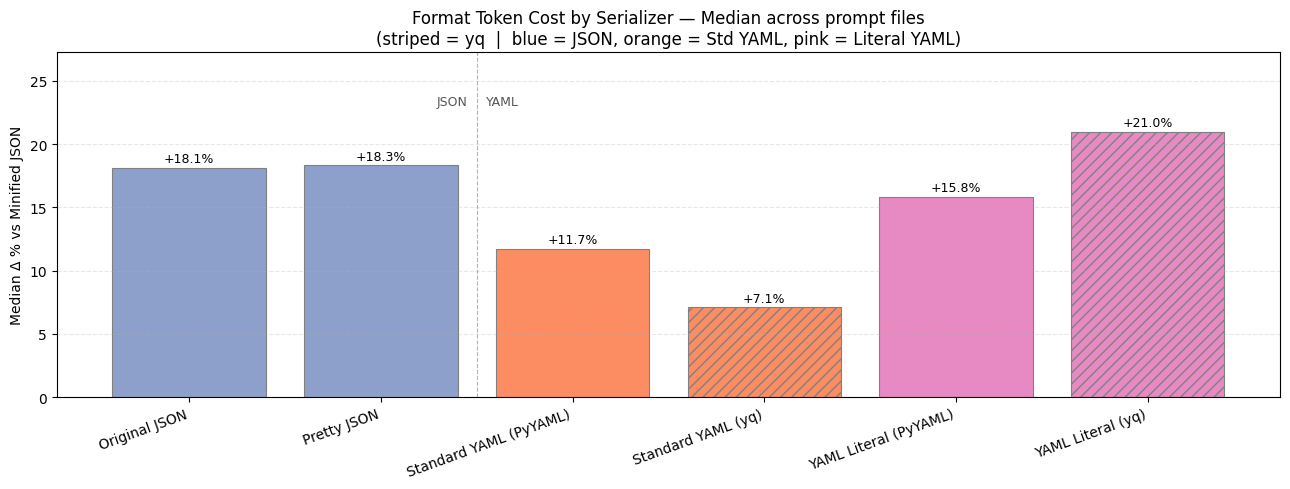

In [5]:
# Bar chart: JSON group (blue) | YAML group (orange/pink); Minified JSON excluded (baseline = 0%)
plot_json = [v for v in JSON_VARIANTS if v != 'Minified JSON']
plot_yaml = YAML_VARIANTS
all_plot  = plot_json + plot_yaml
values    = [median_deltas[v] for v in all_plot]

colors  = (['#8da0cb'] * len(plot_json) +
           ['#fc8d62', '#fc8d62', '#e78ac3', '#e78ac3'])
hatches = ([''] * len(plot_json) +
           ['', '///', '', '///'])

x   = np.arange(len(all_plot))
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(x, values, color=colors, edgecolor='grey', linewidth=0.8)
for bar, hatch, val in zip(bars, hatches, values):
    bar.set_hatch(hatch)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'+{val:.1f}%', ha='center', va='bottom', fontsize=9)

split = len(plot_json) - 0.5
ax.axvline(split, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(split - 0.05, max(values) * 1.1, 'JSON', ha='right', fontsize=9, color='#555')
ax.text(split + 0.05, max(values) * 1.1, 'YAML', ha='left',  fontsize=9, color='#555')

ax.set_xticks(x)
ax.set_xticklabels(all_plot, rotation=20, ha='right')
ax.set_ylabel('Median Δ % vs Minified JSON')
ax.set_title('Format Token Cost by Serializer — Median across prompt files\n'
             '(striped = yq  |  blue = JSON, orange = Std YAML, pink = Literal YAML)')
ax.set_ylim(0, max(values) * 1.3)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

(appendix-yaml-b-isolation)=
## B. Isolation Experiments

Each experiment isolates one serializer variable on the largest prompt file to quantify its independent contribution.

In [6]:
rep_path = PROMPT_FILES[-1]
rep_data = json.loads(rep_path.read_text())
print(f"Representative file: {rep_path.name} ({rep_path.stat().st_size:,} bytes)")

Representative file: local_ai_systems_consultant.json (13,301 bytes)


(appendix-yaml-b1-line-wrapping)=
### B1. Line wrapping — `width=80` vs `width=∞`

:::{note}
`w=N` is shorthand for the `width` parameter of `yaml.dump(data, width=N)`.
`width=80` is the PyYAML default: any string longer than 80 characters is split
across multiple lines, adding one newline token per continuation.
`width=float('inf')` — written `w=∞` here — disables wrapping entirely.
:::

In [7]:
t_min  = tokens(json.dumps(rep_data, ensure_ascii=False, separators=(',', ':')))
t_pretty = tokens(json.dumps(rep_data, ensure_ascii=False, indent=2))
w80    = yaml_standard(rep_data, width=80)
w_inf  = yaml_standard(rep_data, width=float('inf'))
t80, t_inf = tokens(w80), tokens(w_inf)

print(f"Minified JSON:\t\t\t{t_min:>6} tokens  (baseline)")
print(f"Standard YAML width=80:\t\t{t80:>6} tokens  ({len(w80.splitlines())} lines)  "
      f"[{(t80-t_min)/t_min*100:+.1f}% vs min JSON]")
print(f"Standard YAML width=∞:\t\t{t_inf:>6} tokens  ({len(w_inf.splitlines())} lines)  "
      f"[{(t_inf-t_min)/t_min*100:+.1f}% vs min JSON]")
print(f"Pretty JSON:\t\t\t{t_pretty:>6} tokens  [{(t_pretty-t_min)/t_min*100:+.1f}% vs min JSON]")
print(f"\nWrapping overhead:\t\t{t80 - t_inf:>+6} tokens  ({(t80 - t_inf) / t_inf * 100:.1f}%)")
print(f"YAML w=∞ vs Pretty JSON:\t{t_inf - t_pretty:>+6} tokens  "
      f"({'cheaper' if t_inf < t_pretty else 'more expensive'})")

Minified JSON:			  2676 tokens  (baseline)
Standard YAML width=80:		  2985 tokens  (241 lines)  [+11.5% vs min JSON]
Standard YAML width=∞:		  2858 tokens  (170 lines)  [+6.8% vs min JSON]
Pretty JSON:			  3123 tokens  [+16.7% vs min JSON]

Wrapping overhead:		  +127 tokens  (4.4%)
YAML w=∞ vs Pretty JSON:	  -265 tokens  (cheaper)


### B2. Quote style — single quotes vs double quotes

PyYAML's default style leaves most strings unquoted and single-quotes values that
look like dates (`'2026-01-07'`) or contain YAML-special characters. Forcing
`default_style='"'` double-quotes every scalar key and value. This experiment
measures the token cost of that difference in isolation (both use `w=∞` to exclude
line-wrapping effects).

In [8]:
default_style = yaml_standard(rep_data, width=float('inf'))
double_quoted = yaml.dump(rep_data, allow_unicode=True, default_flow_style=False,
                          sort_keys=False, width=float('inf'), default_style='"')

t_def, t_dq = tokens(default_style), tokens(double_quoted)
print(f"Default style (w=∞):       {t_def:>6} tokens")
print(f"Double-quote style (w=∞):  {t_dq:>6} tokens")
print(f"Delta:                     {t_dq - t_def:>+6} tokens")

date_default = [l for l in default_style.splitlines() if re.search(r'202\d-', l)][:3]
date_dquoted = [l for l in double_quoted.splitlines() if re.search(r'202\d-', l)][:3]
print("\nDate quoting — default:")
for l in date_default:
    print(f"  {l}")
print("Date quoting — double-quote:")
for l in date_dquoted:
    print(f"  {l}")

Default style (w=∞):         2858 tokens
Double-quote style (w=∞):    3069 tokens
Delta:                       +211 tokens

Date quoting — default:
    birth: '2025-11-28'
    last_modified: '2026-03-02'
Date quoting — double-quote:
    "birth": "2025-11-28"
    "last_modified": "2026-03-02"


(appendix-yaml-b3)=
### B3. Literal block terminator and boolean coercion

PyYAML's literal representer applies `|` (clip — keep one trailing newline) to
strings only; booleans and numbers stay inline. yq's `..style="literal"` applies
`|-` (strip — no trailing newline) to **all** scalars, including booleans and
numbers. This creates two compounding cost sources:

1. Every string scalar pays for the extra `-` character in the indicator (`|-` vs `|`).
2. Non-string scalars (booleans, numbers) are moved from an inline value to a
   separate indented line, adding newline and indentation tokens.

The cell below decomposes the total delta by progressively transforming the PyYAML
output toward yq's: first changing all `|` indicators to `|-` (Source 1), then
attributing the remainder to structural differences (Source 2). The verification
line confirms the two sources sum to the actual delta exactly.

In [9]:
t_pretty = tokens(json.dumps(rep_data, ensure_ascii=False, indent=2))
py_lit   = yaml_literal(rep_data)
yq_lit   = yq_literal(rep_path)
t_py_lit, t_yq_lit = tokens(py_lit), tokens(yq_lit)

print(f"Pretty JSON:           {t_pretty:>6} tokens  (reference)")
print(f"PyYAML literal (`|`):  {t_py_lit:>6} tokens  [{t_py_lit - t_pretty:+d} vs Pretty JSON]"
      f"  {'← more expensive' if t_py_lit > t_pretty else '← cheaper'}")
print(f"yq literal (`|-`):     {t_yq_lit:>6} tokens  [{t_yq_lit - t_pretty:+d} vs Pretty JSON]"
      f"  {'← more expensive' if t_yq_lit > t_pretty else '← cheaper'}")
print(f"\nPyYAML vs yq literal delta: {t_py_lit - t_yq_lit:+d} tokens  (negative = PyYAML cheaper)")

# --- Decompose the delta by progressively transforming py_lit toward yq_lit ---

# Step 0: baseline
t0 = tokens(py_lit)

# Step 1: change all `|` indicators to `|-` (string scalars only — same content, different indicator)
py_step1 = re.sub(r'(: \|)(\n)', r'\1-\2', py_lit)
t1 = tokens(py_step1)

# Step 2: the remaining gap is everything else — boolean coercion, extra lines, quoting, etc.
# We can't transform py_lit further without reproducing yq's full output,
# so we report the remainder as "structural differences beyond indicators"

py_pipe_count = len(re.findall(r': \|$',  py_lit, re.MULTILINE))
yq_pipe_count = len(re.findall(r': \|-$', yq_lit, re.MULTILINE))
coerced       = re.findall(r'\|-\n(\s+)(true|false|\d+\.?\d*)\n', yq_lit)
n_coerced     = len(coerced)

actual_delta    = t_yq_lit - t0
indicator_cost  = t1 - t0                          # Source 1: `|` → `|-` on string scalars
structural_cost = t_yq_lit - t1                    # Source 2: everything else

print(f"\nDelta breakdown (yq literal − PyYAML literal = {actual_delta:+d} tokens):")
print(f"\n  Source 1 — `|-` vs `|` indicator on {py_pipe_count} string scalars:")
print(f"    Measured on actual document (all `|` → `|-`): {indicator_cost:+d} tokens")
print(f"    Per-indicator cost: {indicator_cost / py_pipe_count:+.1f} tokens")
print(f"\n  Source 2 — structural differences beyond indicators:")
print(f"    yq `|-` blocks (total): {yq_pipe_count}  (PyYAML `|`: {py_pipe_count})")
print(f"    Non-string scalars coerced to `|-`: {n_coerced}  {[v for _, v in coerced[:6]]}")
print(f"    Extra lines in yq: {len(yq_lit.splitlines()) - len(py_lit.splitlines())}")
print(f"    Measured cost (actual yq − step-1 document): {structural_cost:+d} tokens")
print(f"\n  Verification: {indicator_cost:+d} + {structural_cost:+d} = "
      f"{indicator_cost + structural_cost:+d} tokens  (actual: {actual_delta:+d})")

Pretty JSON:             3123 tokens  (reference)
PyYAML literal (`|`):    3058 tokens  [-65 vs Pretty JSON]  ← cheaper
yq literal (`|-`):       3183 tokens  [+60 vs Pretty JSON]  ← more expensive

PyYAML vs yq literal delta: -125 tokens  (negative = PyYAML cheaper)

Delta breakdown (yq literal − PyYAML literal = +125 tokens):

  Source 1 — `|-` vs `|` indicator on 54 string scalars:
    Measured on actual document (all `|` → `|-`): +54 tokens
    Per-indicator cost: +1.0 tokens

  Source 2 — structural differences beyond indicators:
    yq `|-` blocks (total): 59  (PyYAML `|`: 54)
    Non-string scalars coerced to `|-`: 4  ['true', 'true', 'true', 'true']
    Extra lines in yq: 5
    Measured cost (actual yq − step-1 document): +71 tokens

  Verification: +54 + +71 = +125 tokens  (actual: +125)


### B4. Structural diff

Visual confirmation of the serializer differences measured in B1–B3. The standard
YAML diff shows PyYAML's line-wrapping (B1) and quote-style differences (B2). The
literal YAML diff shows the `|` vs `|-` indicator divergence (B3) and boolean
coercion on the last lines.

In [10]:
def show_diff(label_a, text_a, label_b, text_b, max_diffs=8):
    lines_a, lines_b = text_a.splitlines(), text_b.splitlines()
    print(f"Line counts: {label_a}={len(lines_a)}, {label_b}={len(lines_b)}")
    diffs = 0
    for i, (a, b) in enumerate(zip(lines_a, lines_b)):
        if a != b:
            print(f"  [{i}] {label_a}:\t{a!r}")
            print(f"       {label_b}:\t{b!r}")
            diffs += 1
            if diffs >= max_diffs:
                print(f"  ... (stopped at {max_diffs})")
                break
    if diffs == 0:
        print("  No differences in overlapping lines.")

print("=== Standard YAML: PyYAML vs yq ===")
show_diff('PyYAML', yaml_standard(rep_data), 'yq', yq_standard(rep_path))
print("\n=== YAML Literal: PyYAML vs yq ===")
show_diff('PyYAML', yaml_literal(rep_data), 'yq', yq_literal(rep_path))

=== Standard YAML: PyYAML vs yq ===
Line counts: PyYAML=241, yq=165
  [3] PyYAML:	"  birth: '2025-11-28'"
       yq:	'  birth: "2025-11-28"'
  [4] PyYAML:	"  last_modified: '2026-03-02'"
       yq:	'  last_modified: "2026-03-02"'
  [5] PyYAML:	'  purpose: Peer review and critique of architectural and software engineering concepts'
       yq:	'  purpose: Peer review and critique of architectural and software engineering concepts for industrial applications of AI powered systems, featuring internal WRC calculation and self-critique logic.'
  [6] PyYAML:	'    for industrial applications of AI powered systems, featuring internal WRC calculation'
       yq:	'  owner: lefthand67'
  [7] PyYAML:	'    and self-critique logic.'
       yq:	'input_protocol:'
  [8] PyYAML:	'  owner: lefthand67'
       yq:	'  expected_input: Architectural and methodological questions on AI systems.'
  [9] PyYAML:	'input_protocol:'
       yq:	'  input_check:'
  [10] PyYAML:	'  expected_input: Architectural and method

(appendix-yaml-c-fidelity)=
## C. Semantic Fidelity

A serializer that changes values is disqualified for prompt delivery regardless of
token efficiency. We test round-trip fidelity: JSON → YAML (serializer) → JSON and
assert the result equals the original. Any coercion (e.g., string `"true"` →
boolean `true`, or date strings losing their type) would surface as a failure here.

The first cell tests all 5 prompt files with both PyYAML (`w=∞`) and yq.
The second cell tests edge-case scalars that are known to trigger type coercion in
YAML parsers: boolean strings (`"true"`, `"false"`), date-like strings, null, and
numeric values.

In [11]:
def find_diff(a, b, path='root'):
    if isinstance(a, dict) and isinstance(b, dict):
        for k in set(list(a.keys()) + list(b.keys())):
            find_diff(a.get(k), b.get(k), f"{path}.{k}")
    elif isinstance(a, list) and isinstance(b, list):
        for i, (x, y) in enumerate(zip(a, b)):
            find_diff(x, y, f"{path}[{i}]")
    elif a != b:
        print(f"  DIFF at {path}: {a!r} → {b!r}")

print(f"{'File':<45} {'PyYAML':>8} {'yq':>8}")
print('-' * 63)
for path in PROMPT_FILES:
    data = json.loads(path.read_text())
    # yaml.safe_load is safe here: yaml.dump quotes YAML 1.1 implicit types
    # (yes/no/on/off/true/false, date strings) so safe_load recovers them as strings.
    py_rt = yaml.safe_load(yaml_standard(data, width=float('inf')))
    py_ok = py_rt == data
    yq_yaml = yq_standard(path)
    yq_json = subprocess.run(['yq', '-oj', '-'], input=yq_yaml,
                             capture_output=True, text=True).stdout
    yq_rt = json.loads(yq_json)
    yq_ok = yq_rt == data
    print(f"{path.name:<45} {'✓' if py_ok else '✗':>8} {'✓' if yq_ok else '✗':>8}")
    if not py_ok: find_diff(data, py_rt)
    if not yq_ok: find_diff(data, yq_rt)

File                                            PyYAML       yq
---------------------------------------------------------------
handbook_consultant.json                             ✓        ✓
ai_brainstorming_colleague.json                      ✓        ✓
devops_consultant.json                               ✓        ✓
ai_systems_consultant_hybrid.json                    ✓        ✓
local_ai_systems_consultant.json                     ✓        ✓


In [12]:
# Edge case scalars.
# YAML 1.1 implicit types: 'yes'/'no'/'on'/'off' are booleans in YAML 1.1 but not in
# YAML 1.2 or JSON. PyYAML (YAML 1.1) quotes these strings on dump, so safe_load
# recovers them as strings. yq (YAML 1.2 / Go) does not coerce them — both paths
# should round-trip correctly, but we test explicitly to confirm.
edge_cases = {
    'booleans':       {'flag_true': True, 'flag_false': False},
    'numbers':        {'integer': 42, 'float_val': 3.14},
    'null':           {'empty': None},
    'date string':    {'date': '2026-01-07'},
    'bool string':    {'truthy': 'true', 'falsy': 'false'},
    'yaml11 strings': {'yes_str': 'yes', 'no_str': 'no', 'on_str': 'on', 'off_str': 'off'},
}

print(f"{'Scalar type':<15} {'PyYAML w=∞':>12} {'yq':>8}")
print('-' * 37)
for label, test_data in edge_cases.items():
    py_rt = yaml.safe_load(yaml_standard(test_data, width=float('inf')))
    py_ok = py_rt == test_data
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        json.dump(test_data, f)
        tmp = f.name
    try:
        yq_yaml = yq_standard(tmp)
        yq_json = subprocess.run(['yq', '-oj', '-'], input=yq_yaml,
                                 capture_output=True, text=True).stdout
        yq_rt = json.loads(yq_json)
        yq_ok = yq_rt == test_data
    finally:
        os.unlink(tmp)
    print(f"{label:<15} {'✓' if py_ok else f'✗ {py_rt}':>12} {'✓' if yq_ok else f'✗ {yq_rt}':>8}")

Scalar type       PyYAML w=∞       yq
-------------------------------------
booleans                   ✓        ✓
numbers                    ✓        ✓
null                       ✓        ✓
date string                ✓        ✓
bool string                ✓        ✓
yaml11 strings             ✓        ✓


## D. Ranking Stability Across Tokenizers

The serializer variance documented in {ref}`appendix-yaml-a-baseline` and
{ref}`appendix-yaml-b-isolation` was measured with `cl100k_base` (GPT-4,
100k vocab). A natural question: do the findings hold for other tokenizers,
or are they an artifact of one vocabulary?

We test tokenizers across a wide range of vocabulary sizes and training
distributions. Larger vocabularies generally compress more character sequences
into single tokens, so absolute counts differ — but the question is whether
the **relative ordering** between formats and serializers is preserved.

:::{note}
**Gemini and Claude** do not publish standalone downloadable tokenizers.

*Gemini proxy — Gemma 2* (`google/gemma-2-2b`, 256k vocab): the Gemma 2 technical
report states explicitly that it uses "the same tokenizer as Gemma 1 and Gemini: a
SentencePiece tokenizer with split digits, preserved whitespace, and byte-level
encodings" ([Gemma 2: Improving Open Language Models at a Practical Size, arXiv:2408.00118](https://arxiv.org/abs/2408.00118)). Gemma 2 is
therefore the highest-fidelity public proxy for Gemini token counts.

*Claude*: Anthropic's pre-Claude-3 tokenizer is BPE-based with ~64k vocabulary
(confirmed by `bpe_ranks` in the
[official Anthropic tokenizer repo](https://github.com/anthropics/anthropic-tokenizer-typescript)).
The Claude 3+ tokenizer architecture is not publicly documented. For accurate
counts use the API: `anthropic.messages.count_tokens`.

`google/gemma-2-2b` and `meta-llama/Llama-3.2-1B` are gated: accept the licence
agreement on the model page, then authenticate once per environment (see auth cell
below). The download cell loads all candidates with `try/except` and skips any that
are still unavailable.
:::

:::{note}
The warning `Token indices sequence length is longer than the specified maximum
sequence length for this model` is expected and harmless: it is issued by the
HuggingFace tokenizer library when a sequence exceeds the *model's* context
window. We use the tokenizer only to count tokens, not to run inference, so
the counts are valid.
:::

In [13]:
# HuggingFace authentication — required once per environment for gated models.
# Steps:
#   1. Accept licence at https://huggingface.co/google/gemma-2-2b
#   2. Accept licence at https://huggingface.co/meta-llama/Llama-3.2-1B
#   3. Create a read token at https://huggingface.co/settings/tokens
#   4. Uncomment the line below and run this cell (token is cached to ~/.cache/huggingface/):
from huggingface_hub import login; login()

In [14]:
import transformers
transformers.logging.set_verbosity_error()
from transformers import AutoTokenizer

# Claude is excluded: no downloadable tokenizer for Claude 3+.
# Gemma 2 is the recommended Gemini proxy (see note above).
_candidates = [
    ('GPT-2 (50k)',       'openai-community/gpt2'),
    ('Llama 3 (128k)',    'meta-llama/Llama-3.2-1B'),
    ('Qwen3 (151k)',      'Qwen/Qwen3-Embedding-0.6B'),
    ('Gemma 2 (256k)',    'google/gemma-2-2b'),
]

hf_tokenizers = {}
for label, model_id in _candidates:
    try:
        hf_tokenizers[label] = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        print(f'  ✓ {label}')
    except Exception as e:
        print(f'  ✗ {label} — skipped ({e})')

tok_records = []
for tok_label, tokenizer in hf_tokenizers.items():
    for path in PROMPT_FILES:
        data = json.loads(path.read_text())
        vmap = variants_for(path, data)
        for variant, text in vmap.items():
            tok_records.append({
                'tokenizer': tok_label,
                'file':      path.name,
                'group':     'JSON' if variant in JSON_VARIANTS else 'YAML',
                'variant':   variant,
                'tokens':    len(tokenizer.encode(text)),
            })

df_tok = pd.DataFrame(tok_records)
df_tok['variant'] = pd.Categorical(df_tok['variant'], categories=VARIANT_NAMES, ordered=True)

# Median across files — variants as rows, tokenizers as columns
summary_tok = (df_tok
    .groupby(['group', 'variant', 'tokenizer'], observed=True)['tokens']
    .median()
    .astype(int)
    .unstack('tokenizer'))
summary_tok.columns.name = None

# Sort columns left-to-right by vocabulary size
_vocab_k = lambda col: int(re.search(r'(\d+)k', col).group(1)) if re.search(r'\d+k', col) else 0
summary_tok = summary_tok[sorted(summary_tok.columns, key=_vocab_k)]

display(summary_tok.style
        .highlight_min(color='#c7f2a4', axis=0)
        .highlight_max(color='#f2c4c4', axis=0)
        .set_caption('Median token counts by tokenizer — green = min per tokenizer, red = max per tokenizer'))

  ✓ GPT-2 (50k)
  ✓ Llama 3 (128k)
  ✓ Qwen3 (151k)
  ✓ Gemma 2 (256k)


## E. Assessment

The experiments above establish three findings that hold across all 5 production
prompt files, one representative file for isolation, and all tokenizers tested
(cl100k_base in sections A–C, plus GPT-2 50k, Llama 3 128k, Qwen3 151k, and
Gemma 2 256k in section D).

**Finding 1 — The serializer is a hidden variable.**
Minified JSON and Pretty JSON are serializer-stable: `json.dumps()` parameters fully determine their output regardless of tool. Standard YAML and YAML Literal are serializer-unstable: their token counts depend on the tool's line-width policy, quoting style, and scalar coercion rules.

**Finding 2 — Line wrapping (PyYAML `width=80`) is the dominant overhead.**
PyYAML's default wraps long strings at 80 characters, adding newline tokens. Setting `width=float('inf')` eliminates this overhead with no semantic change (confirmed in {ref}`appendix-yaml-c-fidelity`). The exact savings scale with the number of long string values in the prompt. Run cell B1 to measure on any prompt version.

**Finding 3 — yq's literal coercion inflates YAML Literal on documents with boolean or numeric fields.**
`yq -oy '..style="literal"'` applies literal block style to all scalars, including booleans and numbers. This has two compounding effects: every string scalar gets a `|-` indicator instead of `|`, and non-string scalars are moved from an inline value to their own indented line. The exact token cost of each effect is measured in {ref}`appendix-yaml-b3`. On prompt files with many boolean flags this pushes YAML Literal (yq) above Pretty JSON. PyYAML's literal representer applies only to strings. Whether the flip occurs depends on the file — compute it below.

In [15]:
# Per-file rankings — computed from df_wide
PYYAML_VARIANTS = ['Original JSON', 'Minified JSON', 'Pretty JSON', 'Standard YAML (PyYAML)', 'YAML Literal (PyYAML)']
YQ_VARIANTS     = ['Original JSON', 'Minified JSON', 'Pretty JSON', 'Standard YAML (yq)',     'YAML Literal (yq)']

SHORT = {
    'Original JSON':          'Orig JSON',
    'Minified JSON':          'Min JSON',
    'Pretty JSON':            'Pretty JSON',
    'Standard YAML (PyYAML)': 'Std YAML (py)',
    'Standard YAML (yq)':     'Std YAML (yq)',
    'YAML Literal (PyYAML)':  'Lit YAML (py)',
    'YAML Literal (yq)':      'Lit YAML (yq)',
}

flip_records = []
for path in PROMPT_FILES:
    fname = path.name
    row   = df_wide.loc[fname]
    py_sorted = row[PYYAML_VARIANTS].sort_values()
    yq_sorted = row[YQ_VARIANTS].sort_values()
    flip_records.append({
        'file':           fname,
        'PyYAML ranking': ' < '.join(SHORT[v] for v in py_sorted.index),
        'yq ranking':     ' < '.join(SHORT[v] for v in yq_sorted.index),
        'yq flip':        row['YAML Literal (yq)'] > row['Pretty JSON'],
        'py flip':        row['YAML Literal (PyYAML)'] > row['Pretty JSON'],
    })

df_flips = pd.DataFrame(flip_records).set_index('file')
display(df_flips)

print(f"\nFiles where Lit YAML (yq)     > Pretty JSON: {df_flips['yq flip'].sum()}/{len(PROMPT_FILES)}")
print(f"Files where Lit YAML (PyYAML) > Pretty JSON: {df_flips['py flip'].sum()}/{len(PROMPT_FILES)}")

,PyYAML ranking,yq ranking,yq flip,py flip
file,,,,
handbook_consultant.json,Min JSON < Std YAML (py) < Lit YAML (py) < Ori...,Min JSON < Std YAML (yq) < Lit YAML (yq) < Ori...,False,False
ai_brainstorming_colleague.json,Min JSON < Std YAML (py) < Lit YAML (py) < Ori...,Min JSON < Std YAML (yq) < Orig JSON < Pretty ...,True,False
devops_consultant.json,Min JSON < Std YAML (py) < Lit YAML (py) < Ori...,Min JSON < Std YAML (yq) < Orig JSON < Pretty ...,True,False
ai_systems_consultant_hybrid.json,Min JSON < Std YAML (py) < Lit YAML (py) < Ori...,Min JSON < Std YAML (yq) < Orig JSON < Pretty ...,True,False
local_ai_systems_consultant.json,Min JSON < Std YAML (py) < Lit YAML (py) < Ori...,Min JSON < Std YAML (yq) < Orig JSON < Pretty ...,True,False



Files where Lit YAML (yq)     > Pretty JSON: 4/5
Files where Lit YAML (PyYAML) > Pretty JSON: 0/5


## F. Stack Recommendation

Given the findings above, the cheapest semantically lossless YAML configuration is
PyYAML with `width=float('inf')` (Standard YAML, no line-wrapping). This section
quantifies the savings per file and confirms round-trip fidelity on the full corpus.

### F1. Optimal PyYAML configuration

:::{note}
Column names use the same `w=∞` shorthand introduced in
{ref}`appendix-yaml-b1-line-wrapping`: `YAML w=80` is the default PyYAML output;
`YAML w=∞` is `yaml.dump(..., width=float('inf'))` with wrapping disabled.
`YAML w=∞ vs Pretty` shows the token delta between the optimised YAML and Pretty
JSON — negative means YAML is cheaper.
:::

In [16]:
f_records = []
for path in PROMPT_FILES:
    data      = json.loads(path.read_text())
    t_optimal = tokens(yaml_standard(data, width=float('inf')))
    f_records.append({
        'file':               path.name,
        'Orig JSON':          int(df_wide.loc[path.name, 'Original JSON']),
        'Min JSON':           int(df_wide.loc[path.name, 'Minified JSON']),
        'YAML w=80':          int(df_wide.loc[path.name, 'Standard YAML (PyYAML)']),
        'YAML w=∞':           t_optimal,
        # Wrap overhead = tokens eliminated by disabling line-wrapping (w=80 → w=∞)
        'Wrap overhead':      int(df_wide.loc[path.name, 'Standard YAML (PyYAML)']) - t_optimal,
        'Pretty JSON':        int(df_wide.loc[path.name, 'Pretty JSON']),
        'YAML w=∞ vs Pretty': t_optimal - int(df_wide.loc[path.name, 'Pretty JSON']),
    })

df_f = pd.DataFrame(f_records).set_index('file')
df_f.loc['median'] = df_f.median().round(0).astype(int)

display(df_f.style
        .format({'Wrap overhead':      lambda x: f'+{int(x)}',
                 'YAML w=∞ vs Pretty': lambda x: f'{int(x):+d}'})
        .bar(subset=['Wrap overhead'], color='#d5f5e3', vmin=0)
        .map(lambda v: 'color: green' if isinstance(v, (int, float)) and v < 0 else '',
             subset=['YAML w=∞ vs Pretty']))

,Orig JSON,Min JSON,YAML w=80,YAML w=∞,Wrap overhead,Pretty JSON,YAML w=∞ vs Pretty
file,,,,,,,
handbook_consultant.json,1082,872,984,934,+50,1083,-149
ai_brainstorming_colleague.json,1466,1200,1358,1335,+23,1480,-145
devops_consultant.json,2843,2407,2689,2588,+101,2848,-260
ai_systems_consultant_hybrid.json,3007,2581,2882,2759,+123,3011,-252
local_ai_systems_consultant.json,3118,2676,2985,2858,+127,3123,-265
median,2843,2407,2689,2588,+101,2848,-252


### F2. Fidelity check on the optimal configuration

Before adopting `width=float('inf')` in `prepare_prompt.py`, we verify that every
prompt file round-trips losslessly: JSON → `yaml.dump(width=∞)` → `yaml.safe_load`
→ compare with original JSON. A failure here would indicate that `yaml.safe_load`
coerces a value on parse (e.g., a bare date string becoming a `datetime` object).

In [17]:
print("Round-trip fidelity with width=∞ — all prompt files:\n")
all_pass = True
for path in PROMPT_FILES:
    data = json.loads(path.read_text())
    rt = yaml.safe_load(yaml_standard(data, width=float('inf')))
    ok = rt == data
    if not ok:
        all_pass = False
    print(f"  {path.name:<45} {'✓' if ok else '✗ FAILED'}")

print(f"\nAll files pass: {all_pass}")
if all_pass:
    print("""
Recommended configuration for prepare_prompt.py:

    yaml.dump(data, allow_unicode=True, default_flow_style=False,
              sort_keys=False, width=float('inf'))
""")
else:
    failed = [
        path.name for path in PROMPT_FILES
        if yaml.safe_load(yaml_standard(json.loads(path.read_text()), width=float('inf')))
           != json.loads(path.read_text())
    ]
    print(f"\n⚠ Round-trip failures detected in: {failed}")
    print("Investigate with find_diff() from Section C before adopting width=∞.")
    print("Likely cause: a value type that yaml.safe_load coerces on parse")
    print("(e.g. a string that looks like a date or boolean).")

Round-trip fidelity with width=∞ — all prompt files:

  handbook_consultant.json                      ✓
  ai_brainstorming_colleague.json               ✓
  devops_consultant.json                        ✓
  ai_systems_consultant_hybrid.json             ✓
  local_ai_systems_consultant.json              ✓

All files pass: True

Recommended configuration for prepare_prompt.py:

    yaml.dump(data, allow_unicode=True, default_flow_style=False,
              sort_keys=False, width=float('inf'))

